# EDA III: Статистически анализ на суровите данни

## 1. Подготовка (Setup)
Зареждане на библиотеките и данните.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append(os.path.abspath('..'))
from src.data_processing.loader import load_bonn_data

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Raw Data
DATA_PATH = '../data/raw'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/raw'

print(f"Loading data from {DATA_PATH}...")
try:
    X, y = load_bonn_data(DATA_PATH)
    print(f"Loaded X shape: {X.shape}, y shape: {y.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    # Fallback for empty/missing data in test env
    X = np.random.randn(500, 4097)
    y = np.array([0]*200 + [1]*200 + [2]*100)
    print("Using dummy data for visualization structure.")

Loading data from ../data/raw...
Loading 100 files from Z mapped to Class 0...
Loading 100 files from O mapped to Class 0...
Loading 100 files from N mapped to Class 1...
Loading 100 files from F mapped to Class 1...
Loading 100 files from S mapped to Class 2...
Loaded X shape: (500, 4097), y shape: (500,)


## 2. Анализ на нестабилност (3-Sigma Rule)
Ще изчислим какъв процент от точките във всеки сигнал излизат извън диапазона $\mu \pm 3\sigma$. Това е индикатор за наличието на екстремни събития (като спайкове при пристъпи).

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_97817/2089233.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=[class_names[c] for c in y], y=outlier_percentages, palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])


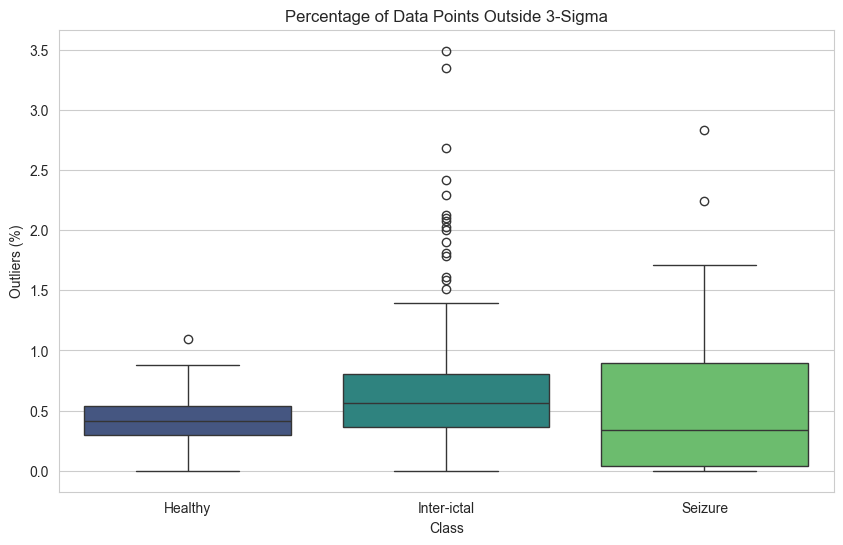

Class Healthy: Mean Outlier % = 0.42%
Class Inter-ictal: Mean Outlier % = 0.70%
Class Seizure: Mean Outlier % = 0.55%


In [2]:
def calculate_outliers_percentage(signal):
    mu = np.mean(signal)
    sigma = np.std(signal)
    
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 3 * sigma
    
    outliers = np.sum((signal < lower_bound) | (signal > upper_bound))
    return (outliers / len(signal)) * 100

# Calculate for all samples
outlier_percentages = np.array([calculate_outliers_percentage(x) for x in X])

# Group by class
class_names = {0: 'Healthy', 1: 'Inter-ictal', 2: 'Seizure'}

plt.figure(figsize=(10, 6))
sns.boxplot(x=[class_names[c] for c in y], y=outlier_percentages, palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])
plt.title('Percentage of Data Points Outside 3-Sigma')
plt.ylabel('Outliers (%)')
plt.xlabel('Class')
plt.show()

# Print stats
for c in [0, 1, 2]:
    class_outliers = outlier_percentages[y == c]
    print(f"Class {class_names[c]}: Mean Outlier % = {np.mean(class_outliers):.2f}%")



3-Sigma правилото зависи от Стандартното отклонение (σ): Формулата за outlier е Value>Mean+3×σ.

При Пристъп (Seizure): Целият сигнал е с огромна амплитуда. Следователно и σ (дисперсията) е огромна. Когато σ е голямо, прагът за "outlier" става много висок. Тоест, сигналът е постоянно силен, а не просто да има "изключения". Той е стабилно хаотичен.

При Интер-иктал (Inter-ictal): Сигналът е предимно спокоен (ниско σ), но от време на време има единични "inter-ictal spikes" (спайкове). Тъй като основното σ е малко, тези единични спайкове лесно прескачат прага и се броят за outliers.

## 3. Класов баланс (Class Imbalance)
Визуализация на разпределението на класовете и изчисляване на Imbalance Ratio.

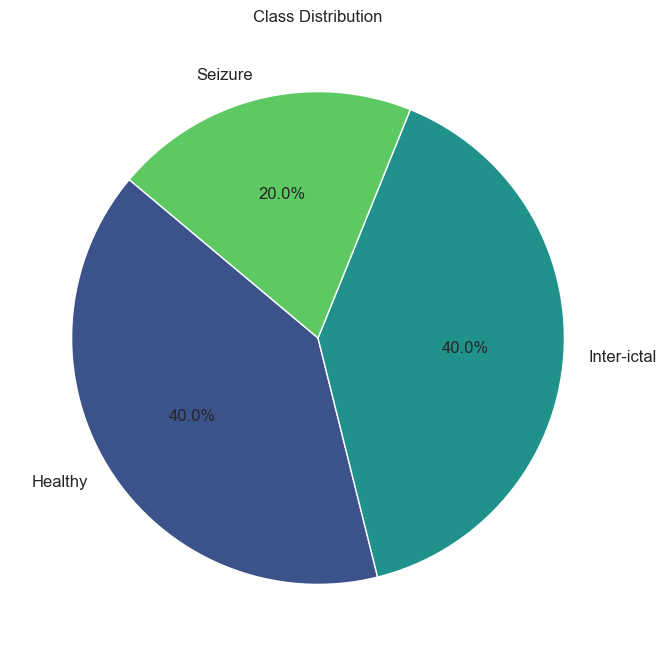

Total Samples: 500
Seizure Samples: 100
Imbalance Ratio (Seizure / Total): 0.2000
Inverse Ratio (Total / Seizure): 5.00


In [3]:
unique, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(unique, counts))

# Prepare data for Pie Chart
labels = [class_names[u] for u in unique]
sizes = counts
colors = sns.color_palette('viridis', len(unique))

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 12})
plt.title('Class Distribution')
plt.show()

# Calculate Imbalance Ratio
total_samples = len(y)
seizure_count = class_counts.get(2, 0)
imbalance_ratio = seizure_count / total_samples

print(f"Total Samples: {total_samples}")
print(f"Seizure Samples: {seizure_count}")
print(f"Imbalance Ratio (Seizure / Total): {imbalance_ratio:.4f}")
print(f"Inverse Ratio (Total / Seizure): {1/imbalance_ratio:.2f}")

Количествен анализ на дисбаланса

Total Samples (500) / Seizure Samples (100):

Епилептичните пристъпи формират малцинствен клас (Minority Class).

Imbalance Ratio (0.20):

Това означава 20% разпространение.

Извод: Всеки модел с Accuracy < 80% е по-слаб от "нулевия" модел (който никога не предсказва пристъп).

Inverse Ratio (5.00):

Това е коефициентът на тежест.

Решение: За да балансираме обучението, грешките при клас Seizure трябва да се наказват с тегло ~5 пъти по-голямо от тези при другите класове (class_weight=5).